# Movies Data Project: Original vs Sequal

## Import packages & Dataset

In [1]:
# Import libraries

# Pandas: used for loading, cleaning, and analyzing tabular data (DataFrames)
import pandas as pd
# NumPy: provides fast numerical operations and arrays for mathematical computations
import numpy as np
# Matplotlib: a core Python library for creating charts and data visualizations
import matplotlib.pyplot as plt
# Seaborn: a high-level visualization library built on Matplotlib for cleaner statistical graphics
import seaborn as sns
# Warnings: allows control or suppression of warning messages that appear during code execution
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Import dataset
movies = pd.read_csv("movies_metadata.csv", low_memory=False)

## Exploratory Analysis

In [2]:
# Display dataset size (rows, columns)
print(movies.shape)

# Display column names, data types, and missing values
print(movies.info())

# Display statistical summary of numeric columns
print(movies.describe().T)

(45466, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  obj

## Original vs Sequel Analysis

In [3]:
# Create a safe copy of the dataset
movies = movies.copy()

# Convert release_date column into a datetime format
# errors="coerce" turns invalid dates into NaT (missing values)
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")

# Some movie datasets store collection info as dictionaries
# These functions safely extract the collection ID and name
def get_collection_id(x):
    # If the value is a dictionary, return the id inside it
    if isinstance(x, dict):
        return x.get("id", np.nan)
    # Otherwise return NaN if missing
    return np.nan if pd.isna(x) else x

def get_collection_name(x):
    # If the value is a dictionary, return the collection name
    if isinstance(x, dict):
        return x.get("name", np.nan)
    return np.nan if pd.isna(x) else x

# Apply the functions to extract collection information
movies["collection_id"] = movies["belongs_to_collection"].apply(get_collection_id)
movies["collection_name"] = movies["belongs_to_collection"].apply(get_collection_name)

# Keep only movies that belong to a collection AND have valid release dates
# These are the only movies that can be analyzed as originals or sequels
collections = movies[
    movies["collection_id"].notna() & movies["release_date"].notna()
].copy()

In [4]:
# Sort movies within each collection by release date
# This determines which movie came first
collections = collections.sort_values(["collection_id", "release_date"])

# Assign installment numbers inside each collection
# The first movie becomes installment 1 (original)
collections["installment_number"] = collections.groupby("collection_id").cumcount() + 1

# Extract the original movies (installment 1)
originals = collections[
    collections["installment_number"] == 1
][
    ["collection_id", "collection_name", "release_date", "title"] + (["id"] if "id" in collections.columns else [])
].rename(columns={
    "title": "original_title",
    "release_date": "original_release_date",
    **({"id": "original_id"} if "id" in collections.columns else {})
})

# Extract sequels (installments 2 or later)
sequels = collections[
    collections["installment_number"] >= 2
][
    ["collection_id", "installment_number", "release_date", "title"] + (["id"] if "id" in collections.columns else [])
].rename(columns={
    "title": "sequel_title",
    "release_date": "sequel_release_date",
    **({"id": "sequel_id"} if "id" in collections.columns else {})
})

# Merge originals with their sequels using collection_id
# This creates pairs: original movie vs sequel movie
pairs = sequels.merge(originals, on="collection_id", how="inner")

In [5]:
# Define the movie performance metrics
metric_cols = [
    "revenue",
    "budget",
    "vote_average",
    "vote_count",
    "popularity",
    "runtime",
    "title"
]

# Include movie id if it exists
if "id" in movies.columns:
    metric_cols.append("id")

# Create a dataframe containing only the metrics
movie_metrics = movies[metric_cols].copy()

# Function that merges performance metrics into the analysis dataset
# This adds revenue, budget, rating, popularity, etc. for each movie
def merge_metrics(df, left_key, prefix):
    # If movie IDs exist, merge using IDs
    if "id" in movies.columns and left_key.endswith("_id"):
        merged = df.merge(
            movie_metrics,
            left_on=left_key,
            right_on="id",
            how="left"
        ).drop(columns=["id"])
    # Otherwise merge using movie titles
    else:
        merged = df.merge(
            movie_metrics,
            left_on=left_key.replace("_id", "_title"),
            right_on="title",
            how="left"
        ).drop(columns=["title"])

    # Rename metrics to indicate whether they belong to original or sequel
    return merged.rename(columns={
        "revenue": f"{prefix}_revenue",
        "budget": f"{prefix}_budget",
        "vote_average": f"{prefix}_rating",
        "vote_count": f"{prefix}_votes",
        "popularity": f"{prefix}_popularity",
        "runtime": f"{prefix}_runtime"
    })

# Create the main analysis dataset
analysis_df = pairs.copy()

# Attach metrics for the original movie
analysis_df = merge_metrics(
    analysis_df,
    "original_id" if "id" in movies.columns else "original_title",
    "original"
)

# Attach metrics for the sequel movie
analysis_df = merge_metrics(
    analysis_df,
    "sequel_id" if "id" in movies.columns else "sequel_title",
    "sequel"
)

### Revenue Comparison: Do Sequels Perform Better Than Originals?

The analysis below compares the box office revenue of original movies and their sequels to determine whether sequels tend to outperform the original film in a franchise.

The summary statistics show that the **average sequel revenue is slightly higher than the average original revenue**, suggesting that sequels can sometimes benefit from an established fan base and brand recognition. However, the **median sequel revenue is lower than the median original revenue**, indicating that many sequels actually perform worse than the original film.

The scatter plot visualizes the relationship between original movie revenue and sequel revenue. Each point represents a pair of movies within the same collection. The red dashed line represents equal revenue between the original and sequel. Points **above the line indicate sequels that earned more than the original**, while points **below the line indicate sequels that earned less**.

The results show that **only about 42% of sequels earned more revenue than their original movie**, meaning that most sequels do not surpass the financial success of the original film. This suggests that while some sequels achieve major success, overall sequel performance is highly variable.

The table of top revenue increases highlights the sequels that achieved the largest financial improvements compared to their originals. These cases demonstrate how certain franchises can grow significantly in popularity over time.

Revenue-based sequel performance:
Mean original revenue: 189,553,639
Mean sequel revenue:   200,525,127
Median original revenue: 101,702,060
Median sequel revenue:   83,080,890

42.05% of sequels earned more revenue than the original.


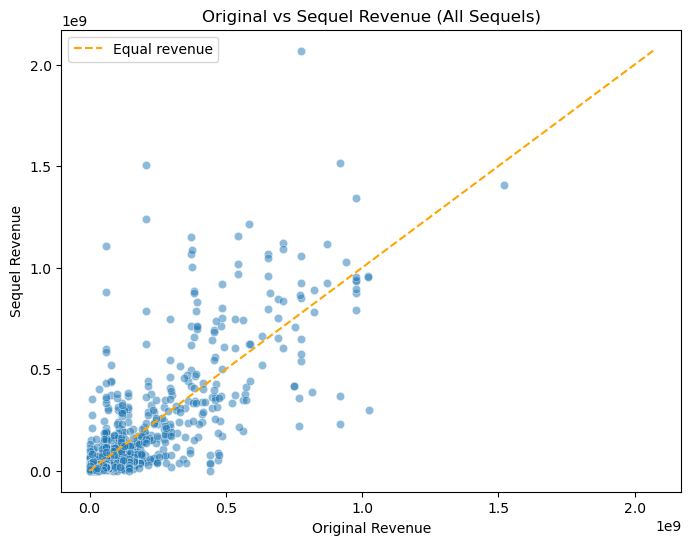

,collection_name,original_title,sequel_title,installment_number,original_revenue,sequel_revenue,revenue_increase,years_since_original
2649,"{'id': 9485, 'name': 'The Fast and the Furious...",The Fast and the Furious,Furious 7,7,207283925.0,1.506249e+09,1.298965e+09,13.774127
5,"{'id': 10, 'name': 'Star Wars Collection', 'po...",Star Wars,Star Wars: The Force Awakens,7,775398007.0,2.068224e+09,1.292826e+09,38.557153
2295,"{'id': 645, 'name': 'James Bond Collection', '...",Dr. No,Skyfall,25,59600000.0,1.108561e+09,1.048961e+09,50.058864
2650,"{'id': 9485, 'name': 'The Fast and the Furious...",The Fast and the Furious,The Fate of the Furious,8,207283925.0,1.238765e+09,1.031481e+09,15.805613
2296,"{'id': 645, 'name': 'James Bond Collection', '...",Dr. No,Spectre,26,59600000.0,8.806746e+08,8.210746e+08,53.059548
449,"{'id': 131295, 'name': 'Captain America Collec...",Captain America: The First Avenger,Captain America: Civil War,3,370569774.0,1.153304e+09,7.827347e+08,4.766598
1246,"{'id': 263, 'name': 'The Dark Knight Collectio...",Batman Begins,The Dark Knight Rises,3,374218673.0,1.084939e+09,7.107204e+08,7.099247
36,"{'id': 10194, 'name': 'Toy Story Collection', ...",Toy Story,Toy Story 3,3,373554033.0,1.066970e+09,6.934157e+08,14.628337
1245,"{'id': 263, 'name': 'The Dark Knight Collectio...",Batman Begins,The Dark Knight,2,374218673.0,1.004558e+09,6.303398e+08,3.099247
447,"{'id': 131292, 'name': 'Iron Man Collection', ...",Iron Man,Iron Man 3,3,585174222.0,1.215440e+09,6.302658e+08,4.966461


In [9]:
# Remove movies with missing or zero revenue values
# The movies need to have valid financial data
analysis_df = analysis_df[
    (analysis_df["original_revenue"] > 0) & 
    (analysis_df["sequel_revenue"] > 0)
].copy()

# Define "successful sequel" as a sequel that earns more revenue than the original
analysis_df["successful_sequel"] = analysis_df["sequel_revenue"] > analysis_df["original_revenue"]

# Calculate the time gap between the original and the sequel (in years)
analysis_df["years_since_original"] = (
    (analysis_df["sequel_release_date"] - analysis_df["original_release_date"]).dt.days / 365.25
)

# Calculate the percentage of sequels that outperform originals
better_rate = analysis_df["successful_sequel"].mean()

# Print summary statistics
print("Revenue-based sequel performance:")
print(f"Mean original revenue: {analysis_df['original_revenue'].mean():,.0f}")
print(f"Mean sequel revenue:   {analysis_df['sequel_revenue'].mean():,.0f}")
print(f"Median original revenue: {analysis_df['original_revenue'].median():,.0f}")
print(f"Median sequel revenue:   {analysis_df['sequel_revenue'].median():,.0f}")
print(f"\n{better_rate:.2%} of sequels earned more revenue than the original.")

# Scatter plot comparing original vs sequel revenue
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=analysis_df,
    x="original_revenue",
    y="sequel_revenue",
    alpha=0.5
)

# Draw a reference line where revenue is equal
max_val = analysis_df[["original_revenue", "sequel_revenue"]].max().max()
plt.plot([0, max_val], [0, max_val], "--", color="Orange", label="Equal revenue")

plt.title("Original vs Sequel Revenue (All Sequels)")
plt.xlabel("Original Revenue")
plt.ylabel("Sequel Revenue")
plt.legend()
plt.show()

# Identify sequels with the largest revenue increases
top_gainers = analysis_df[analysis_df["successful_sequel"]].copy()

# Calculate revenue improvement
top_gainers["revenue_increase"] = (
    top_gainers["sequel_revenue"] - top_gainers["original_revenue"]
)

# Display the top 20 biggest improvements
display(
    top_gainers.sort_values("revenue_increase", ascending=False)[
        [
            "collection_name",
            "original_title",
            "sequel_title",
            "installment_number",
            "original_revenue",
            "sequel_revenue",
            "revenue_increase",
            "years_since_original"
        ]
    ].head(10)
)

## Predicting Successful Sequels Using Machine Learning

A logistic regression model was used to predict whether a sequel would earn more revenue than the original film. 
The model uses several features from the original movie and the franchise, including:

- Original movie budget
- Original rating
- Original popularity
- Original vote count
- Runtime
- Time between releases
- Installment number in the franchise

The goal of the model is to classify sequels into two categories:
- **0 = Sequel is not successful** (earned less revenue than the original)
- **1 = Sequel is successful** (earned more revenue than the original)

The model achieves **about 65% accuracy**, meaning it correctly predicts sequel success roughly two-thirds of the time.  
The **ROC AUC score of ~0.66** indicates the model performs better than random guessing but still has only moderate predictive power.

### Feature Importance (Model Coefficients)

Logistic regression coefficients show how each feature influences the probability of sequel success:

- **Positive coefficients** increase the likelihood that a sequel will outperform the original.
- **Negative coefficients** decrease that likelihood.

In this model, **original vote count and original rating** have the strongest positive relationship with sequel success.  
This suggests that films with strong audience engagement and reception are more likely to produce successful sequels.

---

# Logistic Regression Model Results Explanation

The **classification report** evaluates how well the model predicts sequel success.

## Precision
Precision measures how often the model is correct when it predicts a specific class.

- **Class 0 precision = 0.66**  
  When the model predicts a sequel will *not* be successful, it is correct **66% of the time**.

- **Class 1 precision = 0.61**  
  When the model predicts a sequel *will* be successful, it is correct **61% of the time**.

## Recall
Recall measures how many actual cases the model correctly identifies.

- **Class 0 recall = 0.80**  
  The model correctly identifies **80% of all unsuccessful sequels**.

- **Class 1 recall = 0.43**  
  The model correctly identifies **43% of successful sequels**.

This indicates the model is **better at detecting unsuccessful sequels than successful ones**.

## F1-Score
The F1-score balances precision and recall.

- **Class 0 F1-score = 0.72** (stronger performance predicting unsuccessful sequels)
- **Class 1 F1-score = 0.51** (weaker performance predicting successful sequels)

## Support
Support represents the number of real observations in each class.

- **105 sequels** were labeled **not successful**
- **76 sequels** were labeled **successful**
- **181 total samples** were used in the model

## Accuracy
The model achieves **65% accuracy**, meaning it correctly predicts outcomes **65% of the time**.

---

## Average Metrics

### Macro Average
The **macro average** calculates the average precision, recall, and F1-score while treating each class equally.

- Macro precision = **0.64**
- Macro recall = **0.62**
- Macro F1-score = **0.62**

This means the model performs at roughly **62–64% effectiveness across both classes when weighted equally**.

### Weighted Average
The **weighted average** also calculates averages for precision, recall, and F1-score, but it accounts for the number of samples in each class.

- Weighted precision = **0.64**
- Weighted recall = **0.65**
- Weighted F1-score = **0.63**

Because **Class 0 has more samples**, it influences the weighted average more heavily.

- **Macro average** treats both classes equally.
- **Weighted average** gives more influence to classes with more data.

---

## Interpreting the Boxplot: Original Rating vs Sequel Success

The boxplot compares the **ratings of original movies** based on whether their sequels were financially successful.

- The **x-axis** separates two groups:
  - **False** → sequels that earned less revenue than the original
  - **True** → sequels that earned more revenue than the original

- The **y-axis** shows the **original movie rating**.

### How to Read the Boxplot

- The **middle line** inside each box represents the **median rating**.
- The **box** represents the **interquartile range (IQR)**, containing the middle 50% of ratings.
- **Whiskers** extend to typical minimum and maximum values.
- **Dots outside the whiskers** represent **outliers** (unusually high or low ratings).

### Interpretation

The box for **successful sequels (True)** sits slightly higher than the box for **unsuccessful sequels (False)**.  
This suggests that movies whose sequels outperform them financially tend to have **slightly higher original ratings**.

However, the boxes **overlap significantly**, meaning **rating alone is not a strong predictor of sequel success**.

Some highly rated movies still produce less successful sequels, while some moderately rated movies still produce highly successful ones.

### Overall Conclusion

Higher original ratings may **slightly increase the chances of a successful sequel**, but **multiple factors — including audience engagement, franchise momentum, and other features — play an important role in sequel performance.**


Predicting revenue-based sequel success (Logistic Regression)
              precision    recall  f1-score   support

           0       0.66      0.80      0.72       105
           1       0.61      0.43      0.51        76

    accuracy                           0.65       181
   macro avg       0.64      0.62      0.62       181
weighted avg       0.64      0.65      0.63       181

ROC AUC: 0.658


,feature,coefficient
2,original_votes,0.625340
1,original_rating,0.331651
5,years_since_original,0.273114
6,installment_number,0.179183
4,original_runtime,-0.045530
3,original_popularity,-0.221253
0,original_budget,-0.230401


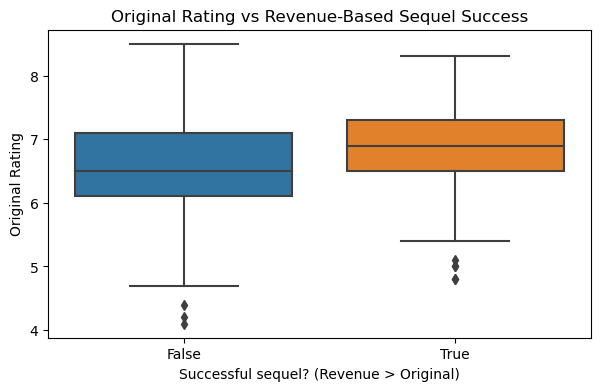

In [8]:
# Import machine learning tools from scikit-learn

# Splits datasets into training and testing subsets (e.g., 80/20 split) to evaluate model performance
from sklearn.model_selection import train_test_split
# Standardizes features by removing the mean and scaling to unit variance (important for many ML algorithms)
from sklearn.preprocessing import StandardScaler
# Creates a workflow that chains multiple steps together (e.g., scaling → model) so they run sequentially
from sklearn.pipeline import Pipeline
# Implements Logistic Regression, a classification algorithm used for predicting probabilities of classes
from sklearn.linear_model import LogisticRegression
# Evaluation metrics:
# - roc_auc_score: Measures how well the model separates classes using the ROC-AUC metric
# - classification_report: Generates precision, recall, F1-score, and support for each class
from sklearn.metrics import roc_auc_score, classification_report

# Define predictor variables used to predict sequel success
predictors = [
    "original_budget",
    "original_rating",
    "original_votes",
    "original_popularity",
    "original_runtime",
    "years_since_original",
    "installment_number"
]

# Prepare dataset for modeling
model_df = (
    analysis_df[predictors + ["successful_sequel"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = model_df[predictors]
y = model_df["successful_sequel"].astype(int)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Build a pipeline that scales features then trains logistic regression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

# Train the model
pipe.fit(X_train, y_train)

# Generate predictions
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

# Print model evaluation metrics
print("\nPredicting revenue-based sequel success (Logistic Regression)")
print(classification_report(y_test, pred))
print(f"ROC AUC: {roc_auc_score(y_test, proba):.3f}")

# Show model coefficients (importance of each feature)
coefs = pipe.named_steps["model"].coef_[0]
coef_table = pd.DataFrame({
    "feature": predictors,
    "coefficient": coefs
}).sort_values("coefficient", ascending=False)

display(coef_table)

# Boxplot comparing original ratings for successful vs unsuccessful sequels
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=analysis_df,
    x="successful_sequel",
    y="original_rating"
)
plt.title("Original Rating vs Revenue-Based Sequel Success")
plt.xlabel("Successful sequel? (Revenue > Original)")
plt.ylabel("Original Rating")
plt.show()